<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving people_nndl.jpg to people_nndl.jpg


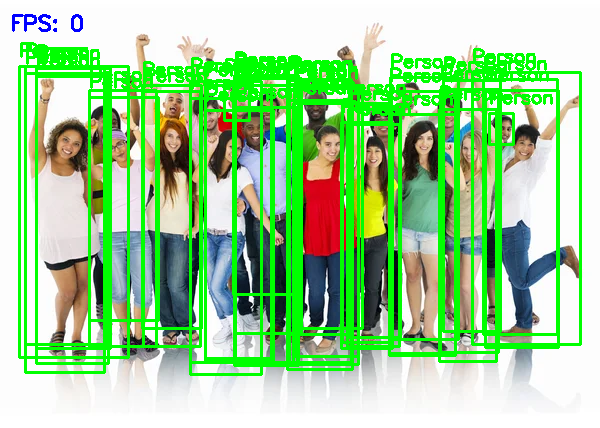

In [1]:
# Problem Statement:
# A home-automation startup wants a real-time security camera that alerts
# when a person enters a room. Build an object detection system and
# measure FPS and detection accuracy.

# -------------------------------
# Step 1: Download YOLO files
# -------------------------------
!wget -q https://pjreddie.com/media/files/yolov3.weights
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# -------------------------------
# Step 2: Import Libraries
# -------------------------------
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import time

# -------------------------------
# Step 3: Load YOLO
# -------------------------------
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

classes = open("coco.names").read().strip().split("\n")

# -------------------------------
# Step 4: Upload Image (Colab)
# -------------------------------
from google.colab import files
uploaded = files.upload()

img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)
h, w = img.shape[:2]

# -------------------------------
# Step 5: Detection + FPS
# -------------------------------
start = time.time()

blob = cv2.dnn.blobFromImage(img, 0.00392, (416,416), (0,0,0), True)
net.setInput(blob)
outs = net.forward(net.getUnconnectedOutLayersNames())

for out in outs:
    for det in out:
        scores = det[5:]
        class_id = np.argmax(scores)

        if classes[class_id] == "person" and scores[class_id] > 0.5:
            cx, cy, bw, bh = (det[0:4] * [w,h,w,h]).astype(int)
            x, y = int(cx - bw/2), int(cy - bh/2)

            cv2.rectangle(img, (x,y), (x+bw,y+bh), (0,255,0), 2)
            cv2.putText(img, "Person", (x,y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

end = time.time()
fps = 1 / (end - start)

cv2.putText(img, f"FPS: {int(fps)}", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

# -------------------------------
# Step 6: Show Output
# -------------------------------
cv2_imshow(img)